In [217]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
    classification_report,
    precision_recall_fscore_support,
    balanced_accuracy_score,
    cohen_kappa_score,
    matthews_corrcoef,
)
from sklearn.preprocessing import label_binarize
import torch
import seaborn as sns
import torch.nn as nn
import matplotlib.pyplot as plt
from typing import List, Tuple

# Global seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [218]:
def basic_eda(df):
    if "Id" in df.columns:
        print(">>> Dropping 'Id' column...")
        df.drop(columns=["Id"], inplace=True)

    print("=== First 5 rows ===")
    display(df.head())

    print("=== Dataset shape ===")
    print(df.shape)

    print("\n=== Info ===")
    df.info()

    print("\n=== Missing values ===")
    print(df.isnull().sum())

    print("\n=== Stats ===")
    display(df.describe())

    # distribution of target
    if "quality" in df.columns:
        print("\n=== Target Distribution (quality) ===")
        # Додано: Вивід кількості кожного класу в консоль
        print(df["quality"].value_counts()) 
        
        plt.figure(figsize=(5,4))
        sns.countplot(x=df["quality"])
        plt.title("Quality distribution")
        plt.show()

    # correlations (exclude target)
    drop_cols = [c for c in ["quality"] if c in df.columns]
    corr_df = df.drop(columns=drop_cols)
    
    print("\n=== Correlation Matrix (features only) ===")
    # Додано: Вивід матриці кореляції в консоль
    display(corr_df.corr())
    
    plt.figure(figsize=(10,8))
    sns.heatmap(corr_df.corr(), cmap="coolwarm", annot=True, fmt=".2f")
    plt.title("Correlation Heatmap (features only)")
    plt.show()

>>> Dropping 'Id' column...
=== First 5 rows ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


=== Dataset shape ===
(1143, 12)

=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB

=== Missing values ===
fixed acidity           0
volatile acidity        0
cit

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000



=== Target Distribution (quality) ===
quality
5    483
6    462
7    143
4     33
8     16
3      6
Name: count, dtype: int64


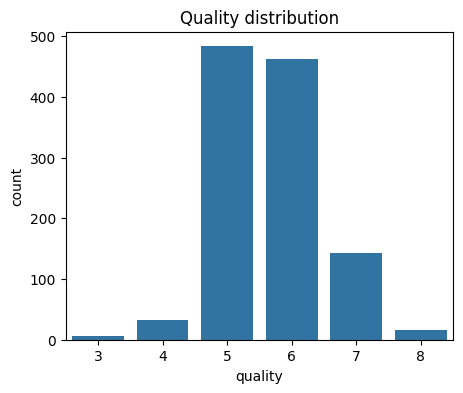


=== Correlation Matrix (features only) ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
fixed acidity,1.000000,-0.250728,0.673157,0.171831,0.107889,-0.164831,-0.110628,0.681501,-0.685163,0.174592,-0.075055
volatile acidity,-0.250728,1.000000,-0.544187,-0.005751,0.056336,-0.001962,0.077748,0.016512,0.221492,-0.276079,-0.203909
citric acid,0.673157,-0.544187,1.000000,0.175815,0.245312,-0.057589,0.036871,0.375243,-0.546339,0.331232,0.106250
residual sugar,0.171831,-0.005751,0.175815,1.000000,0.070863,0.165339,0.190790,0.380147,-0.116959,0.017475,0.058421
chlorides,0.107889,0.056336,0.245312,0.070863,1.000000,0.015280,0.048163,0.208901,-0.277759,0.374784,-0.229917
free sulfur dioxide,-0.164831,-0.001962,-0.057589,0.165339,0.015280,1.000000,0.661093,-0.054150,0.072804,0.034445,-0.047095
total sulfur dioxide,-0.110628,0.077748,0.036871,0.190790,0.048163,0.661093,1.000000,0.050175,-0.059126,0.026894,-0.188165
density,0.681501,0.016512,0.375243,0.380147,0.208901,-0.054150,0.050175,1.000000,-0.352775,0.143139,-0.494727
pH,-0.685163,0.221492,-0.546339,-0.116959,-0.277759,0.072804,-0.059126,-0.352775,1.000000,-0.185499,0.225322
sulphates,0.174592,-0.276079,0.331232,0.017475,0.374784,0.034445,0.026894,0.143139,-0.185499,1.000000,0.094421


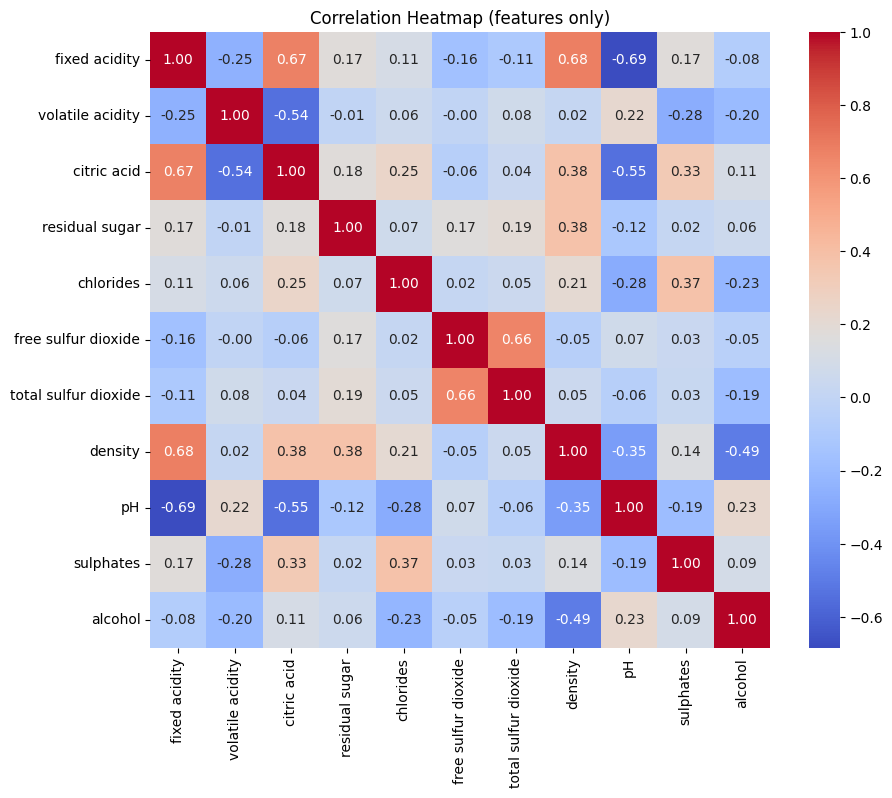

In [219]:
csv_path = "data/WineQT.csv"   

df = pd.read_csv(csv_path)
basic_eda(df)


In [220]:
def preprocess(df, test_size=0.2, val_size=0.1, random_state=42):
    # select feature columns, excluding target and non-features
    feature_cols = [c for c in df.columns if c not in ['quality', 'Id']]
    X = df[feature_cols].values
    y = df['quality'].values

    # Encode labels
    classes, y_enc = np.unique(y, return_inverse=True)

    # split first: train/val/test
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y_enc, test_size=test_size, stratify=y_enc, random_state=random_state
    )

    val_rel = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=val_rel, stratify=y_trainval, random_state=random_state
    )

    # Standardize using train statistics only (avoid leakage)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    # convert to torch tensors
    return (
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.long),

        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.long),

        torch.tensor(X_test, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.long),

        classes,
        scaler
    )

In [221]:
class ActivationFunctions:
    @staticmethod
    def relu(x, derivative=False):
        if not derivative:
            return np.maximum(0, x)
        return (x > 0).astype(np.float32)

    @staticmethod
    def tanh(x, derivative=False):
        if not derivative:
            return np.tanh(x)
        return 1 - np.tanh(x)**2

    @staticmethod
    def softmax(x, derivative=False):
        ex = np.exp(x - np.max(x, axis=1, keepdims=True))
        s = ex / np.sum(ex, axis=1, keepdims=True)
        return s  # derivative handled in CE loss


In [222]:
class LossFunctions:
    @staticmethod
    def cross_entropy(p, y, derivative=False):
        m = p.shape[0]
        if not derivative:
            eps = 1e-12
            correct = p[np.arange(m), y]
            return -np.mean(np.log(correct + eps))
        else:
            grad = p.copy()
            grad[np.arange(m), y] -= 1
            return grad / m


In [223]:
class CustomMLP:
    def __init__(self, layer_sizes, activations, lr=0.01, seed=42):
        np.random.seed(seed)
        self.layer_sizes = layer_sizes
        self.activations = activations
        self.lr = lr
        self.L = len(layer_sizes) - 1

        self.params = {}
        for i in range(1, self.L+1):
            in_dim = layer_sizes[i-1]
            out_dim = layer_sizes[i]
            limit = np.sqrt(6/(in_dim+out_dim))
            self.params[f"W{i}"] = np.random.uniform(-limit, limit, (out_dim, in_dim)).astype(np.float32)
            self.params[f"b{i}"] = np.zeros((out_dim,1), dtype=np.float32)

    def act(self, name, x, derivative=False):
        if name == "relu":  return ActivationFunctions.relu(x, derivative)
        if name == "tanh":  return ActivationFunctions.tanh(x, derivative)
        if name == "softmax": return ActivationFunctions.softmax(x, derivative)
        raise ValueError("unknown activation")

    def forward(self, X):
        A = X.numpy()
        cache = {"A0": A.T}
        A_prev = A.T

        for i in range(1, self.L+1):
            W = self.params[f"W{i}"]
            b = self.params[f"b{i}"]

            Z = W @ A_prev + b

            if self.activations[i-1] == "softmax":
                A = ActivationFunctions.softmax(Z.T).T
            else:
                A = self.act(self.activations[i-1], Z)

            cache[f"Z{i}"] = Z
            cache[f"A{i}"] = A
            A_prev = A

        probs = A_prev.T
        return probs, cache

    def backward(self, X, y, cache):
        m = X.shape[0]
        probs = cache[f"A{self.L}"].T
        y_np = y.numpy()

        # cross-entropy gradient already averaged over batch (1/m factor included)
        dZ = LossFunctions.cross_entropy(probs, y_np, derivative=True).T

        for i in reversed(range(1, self.L+1)):
            A_prev = cache[f"A{i-1}"]
            dW = dZ @ A_prev.T  # no extra /m here
            db = np.sum(dZ, axis=1, keepdims=True)  # no extra /m here

            self.params[f"W{i}"] -= self.lr * dW
            self.params[f"b{i}"] -= self.lr * db

            if i > 1:
                W = self.params[f"W{i}"]
                dA_prev = W.T @ dZ
                Z_prev = cache[f"Z{i-1}"]
                act = self.activations[i-2]

                if act == "relu":
                    dZ = dA_prev * ActivationFunctions.relu(Z_prev, derivative=True)
                elif act == "tanh":
                    dZ = dA_prev * ActivationFunctions.tanh(Z_prev, derivative=True)

        loss = LossFunctions.cross_entropy(probs, y_np)
        acc = np.mean(np.argmax(probs, axis=1) == y_np)

        return loss, acc

    def predict(self, X):
        p, _ = self.forward(X)
        return np.argmax(p, axis=1)

In [224]:
def train_custom(model, X_train, y_train, X_val, y_val, epochs=50, batch_size=64):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    m = X_train.shape[0]

    for ep in range(epochs):
        perm = torch.randperm(m)
        total_loss = 0
        total_acc = 0

        for i in range(0, m, batch_size):
            idx = perm[i:i+batch_size]
            Xb = X_train[idx]
            yb = y_train[idx]

            _, cache = model.forward(Xb)
            loss, acc = model.backward(Xb, yb, cache)

            total_loss += loss * len(Xb)
            total_acc += acc * len(Xb)

        total_loss /= m
        total_acc /= m

        # validation
        p_val, _ = model.forward(X_val)
        val_loss = LossFunctions.cross_entropy(p_val, y_val.numpy())
        val_acc = np.mean(np.argmax(p_val, axis=1) == y_val.numpy())

        history["train_loss"].append(total_loss)
        history["train_acc"].append(total_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        # print(f"Epoch {ep+1}/{epochs}: loss={total_loss:.4f}, acc={total_acc:.4f}, val_acc={val_acc:.4f}")

    return history


In [225]:
class PyTorchMLP(nn.Module):
    def __init__(self, input_dim, hidden, output_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden[0]), nn.Tanh(),
            nn.Linear(hidden[0], hidden[1]), nn.Tanh(),
            nn.Linear(hidden[1], output_dim)
        )

    def forward(self, x):
        return self.model(x)


In [226]:
def train_pytorch(model, X_train, y_train, X_val, y_val, epochs=50, batch_size=64, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    
    m = X_train.shape[0]
    for ep in range(epochs):
        perm = torch.randperm(m)
        tot_loss = 0
        tot_acc = 0

        for i in range(0, m, batch_size):
            idx = perm[i:i+batch_size]
            Xb = X_train[idx]
            yb = y_train[idx]

            opt.zero_grad()
            out = model(Xb)
            loss = loss_fn(out, yb)
            loss.backward()
            opt.step()

            tot_loss += loss.item() * len(Xb)
            tot_acc += (out.argmax(1) == yb).sum().item()

        tot_loss /= m
        tot_acc /= m

        with torch.no_grad():
            out_val = model(X_val)
            val_loss = loss_fn(out_val, y_val).item()
            val_acc = (out_val.argmax(1) == y_val).float().mean().item()

        history["train_loss"].append(tot_loss)
        history["train_acc"].append(tot_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        # print(f"[PT] {ep+1}/{epochs}: loss={tot_loss:.3f}, acc={tot_acc:.3f}, val_acc={val_acc:.3f}")

    return history


In [227]:
X_train, y_train, X_val, y_val, X_test, y_test, classes, scaler = preprocess(df)

input_dim = X_train.shape[1]
hidden = [32, 16]
output_dim = len(classes)

custom = CustomMLP(
    layer_sizes=[input_dim, 32, 16, output_dim],
    activations=["tanh", "tanh", "softmax"],
    lr=0.01
)

history_custom = train_custom(custom, X_train, y_train, X_val, y_val)

preds_custom = custom.predict(X_test)
print("Custom Test Accuracy:", accuracy_score(y_test.numpy(), preds_custom))

Custom Test Accuracy: 0.6724890829694323


In [228]:
pt = PyTorchMLP(input_dim, hidden, output_dim)

history_pt = train_pytorch(pt, X_train, y_train, X_val, y_val)

with torch.no_grad():
    preds_pt = pt(X_test).argmax(1).cpu().numpy()
    print("PyTorch Test Accuracy:", accuracy_score(y_test.numpy(), preds_pt))

PyTorch Test Accuracy: 0.6244541484716157


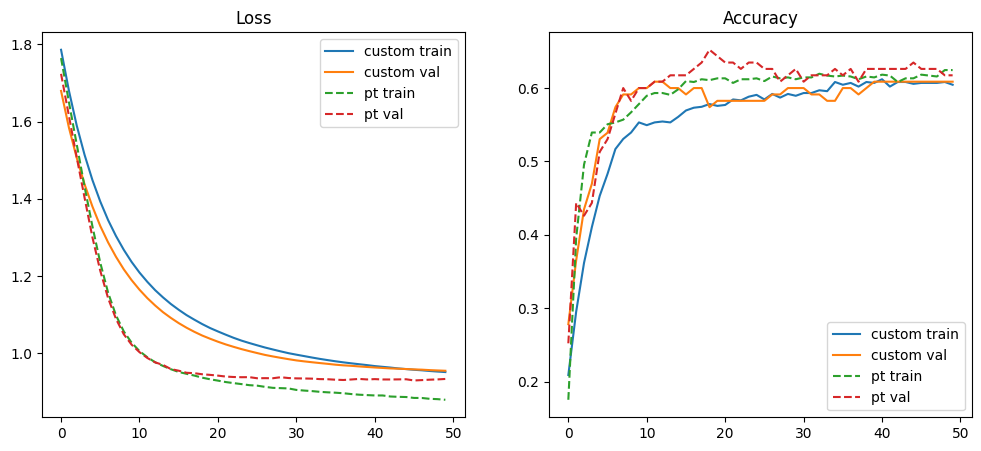

In [229]:
def plot_history(h1, h2):
    plt.figure(figsize=(12,5))
    
    # Loss
    plt.subplot(1,2,1)
    plt.plot(h1["train_loss"], label="custom train")
    plt.plot(h1["val_loss"], label="custom val")
    plt.plot(h2["train_loss"], label="pt train", linestyle="--")
    plt.plot(h2["val_loss"], label="pt val", linestyle="--")
    plt.title("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(h1["train_acc"], label="custom train")
    plt.plot(h1["val_acc"], label="custom val")
    plt.plot(h2["train_acc"], label="pt train", linestyle="--")
    plt.plot(h2["val_acc"], label="pt val", linestyle="--")
    plt.title("Accuracy")
    plt.legend()

    plt.show()

plot_history(history_custom, history_pt)


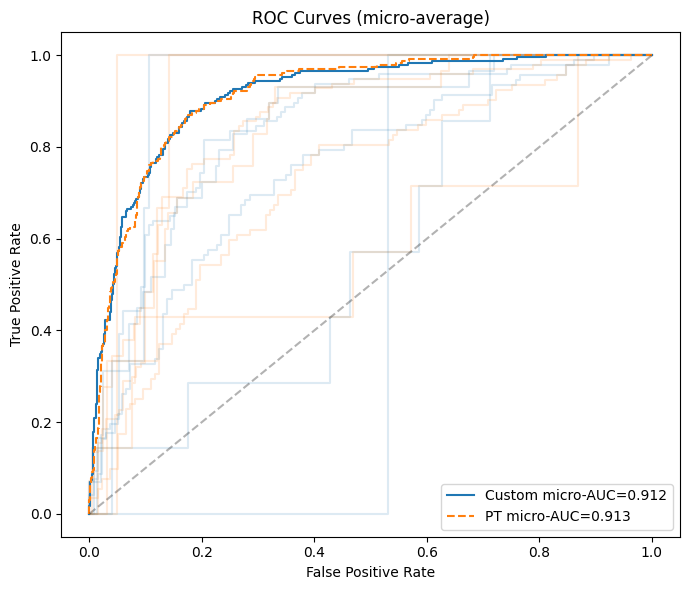

Macro-AUC: Custom=0.732, PT=0.806
Macro-AUC: Custom=0.912, PT=0.913


In [230]:
# ROC/AUC plots (multiclass: per-class faint + micro-average)

def plot_roc_auc(custom_model, pt_model, X, y, classes):
    n_classes = len(classes)
    y_true = y.numpy()
    Y = label_binarize(y_true, classes=np.arange(n_classes))

    # Custom model probabilities
    probs_custom, _ = custom_model.forward(X)  # shape (N, C)

    # PyTorch model probabilities
    with torch.no_grad():
        logits = pt_model(X)
        probs_pt = torch.softmax(logits, dim=1).cpu().numpy()

    # Per-class ROC and AUC
    fpr_c, tpr_c, aucs_c = [], [], []
    fpr_p, tpr_p, aucs_p = [], [], []
    for i in range(n_classes):
        fpr_ci, tpr_ci, _ = roc_curve(Y[:, i], probs_custom[:, i])
        fpr_pi, tpr_pi, _ = roc_curve(Y[:, i], probs_pt[:, i])
        fpr_c.append(fpr_ci); tpr_c.append(tpr_ci); aucs_c.append(auc(fpr_ci, tpr_ci))
        fpr_p.append(fpr_pi); tpr_p.append(tpr_pi); aucs_p.append(auc(fpr_pi, tpr_pi))

    macro_auc_c = float(np.mean(aucs_c))
    macro_auc_p = float(np.mean(aucs_p))

    # Micro-average ROC
    fpr_micro_c, tpr_micro_c, _ = roc_curve(Y.ravel(), probs_custom.ravel())
    fpr_micro_p, tpr_micro_p, _ = roc_curve(Y.ravel(), probs_pt.ravel())
    auc_micro_c = auc(fpr_micro_c, tpr_micro_c)
    auc_micro_p = auc(fpr_micro_p, tpr_micro_p)

    plt.figure(figsize=(7,6))
    # Faint per-class curves
    for i in range(n_classes):
        plt.plot(fpr_c[i], tpr_c[i], color='C0', alpha=0.15)
        plt.plot(fpr_p[i], tpr_p[i], color='C1', alpha=0.15)
    # Micro-average curves
    plt.plot(fpr_micro_c, tpr_micro_c, color='C0', label=f'Custom micro-AUC={auc_micro_c:.3f}')
    plt.plot(fpr_micro_p, tpr_micro_p, color='C1', linestyle='--', label=f'PT micro-AUC={auc_micro_p:.3f}')
    plt.plot([0,1], [0,1], 'k--', alpha=0.3)
    plt.title('ROC Curves (micro-average)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Macro-AUC: Custom={macro_auc_c:.3f}, PT={macro_auc_p:.3f}")
    print(f"Macro-AUC: Custom={auc_micro_c:.3f}, PT={auc_micro_p:.3f}")


# Plot ROC/AUC on test set
plot_roc_auc(custom, pt, X_test, y_test, classes)

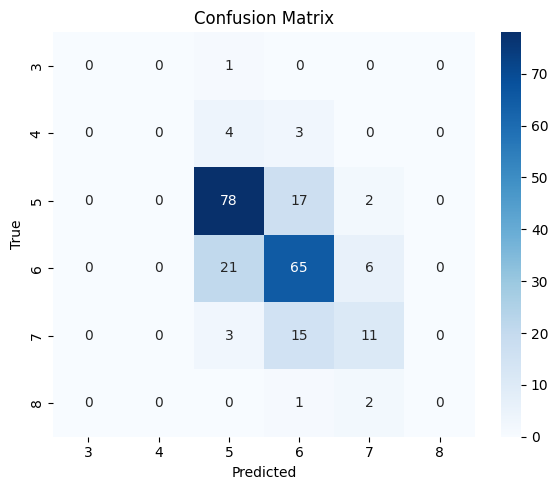

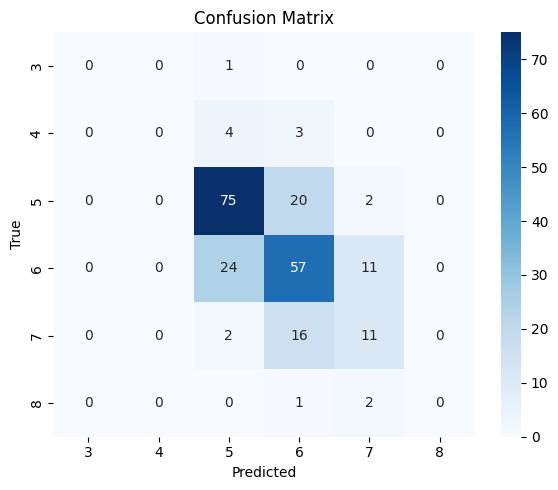

In [231]:
def plot_confusion(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", xticklabels=classes, yticklabels=classes)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

plot_confusion(y_test.numpy(), preds_custom, classes)
plot_confusion(y_test.numpy(), preds_pt, classes)

In [232]:
# Compute and display additional metrics for test set

def summarize_model_metrics(y_true, y_pred, label_names):
    labels = list(range(len(label_names)))
    # classification report (both text and dict)
    report_text = classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=[str(c) for c in label_names],
        zero_division=0,
    )
    report_dict = classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=[str(c) for c in label_names],
        zero_division=0,
        output_dict=True,
    )
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_precision": report_dict["macro avg"]["precision"],
        "macro_recall": report_dict["macro avg"]["recall"],
        "macro_f1": report_dict["macro avg"]["f1-score"],
        "weighted_f1": report_dict["weighted avg"]["f1-score"],
        "kappa": cohen_kappa_score(y_true, y_pred),
        "mcc": matthews_corrcoef(y_true, y_pred),
    }
    return metrics, report_text

# y_true as numpy
_y_true = y_test.numpy()

custom_metrics, custom_report = summarize_model_metrics(_y_true, preds_custom, classes)
pt_metrics, pt_report = summarize_model_metrics(_y_true, preds_pt, classes)

summary_df = pd.DataFrame([custom_metrics, pt_metrics], index=["Custom", "PyTorch"]).round(3)
print("=== Summary Metrics (Test) ===")
display(summary_df)

print("\n=== Classification Report — Custom MLP ===")
print(custom_report)

print("\n=== Classification Report — PyTorch ===")
print(pt_report)

=== Summary Metrics (Test) ===


,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,kappa,mcc
Custom,0.672,0.315,0.316,0.315,0.313,0.650,0.466,0.469
PyTorch,0.624,0.295,0.286,0.295,0.290,0.606,0.394,0.395



=== Classification Report — Custom MLP ===
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.73      0.80      0.76        97
           6       0.64      0.71      0.67        92
           7       0.52      0.38      0.44        29
           8       0.00      0.00      0.00         3

    accuracy                           0.67       229
   macro avg       0.32      0.31      0.31       229
weighted avg       0.63      0.67      0.65       229


=== Classification Report — PyTorch ===
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.71      0.77      0.74        97
           6       0.59      0.62      0.60        92
           7       0.42      0.38      0.40        29
           8       0.00      0.00      0.00    

# Відповіді на контрольні питання

## 1. Похідна комбінації Softmax + Cross-Entropy

**Завдання:** Довести, що градієнт функції втрат $L$ по відношенню до логітів $z_i$ (входів у Softmax) дорівнює $\frac{\partial L}{\partial z_i} = p_i - y_i$.

**Доведення:**
Розглянемо функцію втрат Categorical Cross-Entropy для одного прикладу:
$$L = - \sum_{k} y_k \log(p_k)$$
де $y_k$ — це one-hot вектор істинних міток (1 для правильного класу, 0 для інших), а $p_k$ — вихід Softmax:
$$p_k = \frac{e^{z_k}}{\sum_{j} e^{z_j}}$$

Нам потрібно знайти похідну $\frac{\partial L}{\partial z_i}$. Використовуємо ланцюгове правило:
$$\frac{\partial L}{\partial z_i} = \sum_{k} \frac{\partial L}{\partial p_k} \cdot \frac{\partial p_k}{\partial z_i}$$

1.  **Похідна функції втрат:**
    $$\frac{\partial L}{\partial p_k} = -\frac{y_k}{p_k}$$

2.  **Похідна Softmax ($\frac{\partial p_k}{\partial z_i}$):**
    Тут є два випадки:
    * Якщо $k = i$: $\frac{\partial p_i}{\partial z_i} = p_i(1 - p_i)$
    * Якщо $k \neq i$: $\frac{\partial p_k}{\partial z_i} = -p_k p_i$

3.  **Підставимо у суму:**
    $$\frac{\partial L}{\partial z_i} = -\frac{y_i}{p_i} p_i(1 - p_i) + \sum_{k \neq i} \left( -\frac{y_k}{p_k} (-p_k p_i) \right)$$
    $$\frac{\partial L}{\partial z_i} = -y_i(1 - p_i) + \sum_{k \neq i} y_k p_i$$
    $$\frac{\partial L}{\partial z_i} = -y_i + y_i p_i + p_i \sum_{k \neq i} y_k$$

    Винесемо $p_i$ за дужки для другої частини:
    $$\frac{\partial L}{\partial z_i} = -y_i + p_i (y_i + \sum_{k \neq i} y_k)$$

    Оскільки $y$ — це one-hot вектор, сума всіх його елементів $\sum_k y_k = 1$. Тому вираз у дужках дорівнює 1.
    $$\frac{\partial L}{\partial z_i} = p_i - y_i$$

**Пояснення простоти[cite: 114]:**
Ця формула така проста тому, що функції Softmax (експонента) та Cross-Entropy (логарифм) є взаємно оберненими в контексті математичної статистики. Softmax є канонічною функцією зв'язку (canonical link function) для мультиноміального розподілу, а Cross-Entropy — це логарифм правдоподібності (log-likelihood) для нього. Їх комбінація призводить до лінійної помилки (різниці між прогнозом і фактом), що робить градієнтний спуск ефективним і стабільним.

---

## 2. Аналіз зміни градієнтів у глибоких мережах

**Ситуація:** Мережа з 5 шарами, ReLU активація, 60% нейронів мають від'ємні значення на вході (мертві нейрони).

**Аналіз:**
Похідна ReLU ($f'(x)$) визначається як:
* $1$, якщо $x > 0$
* $0$, якщо $x \le 0$[cite: 117].

Якщо 60% нейронів у прихованих шарах мають від'ємні значення, це призводить до проблеми **"мертвих нейронів" (Dead ReLU)**. Градієнт через такий нейрон стає рівним 0 і не проходить далі назад до попередніх шарів.

Оскільки градієнт для ваг першого шару обчислюється за ланцюговим правилом як добуток похідних усіх наступних шарів:
$$\frac{\partial L}{\partial W_1} \propto f'_2(z_2) \cdot f'_3(z_3) \cdot ... \cdot f'_5(z_5)$$
Якщо хоча б один нейрон на шляху проходження сигналу "мертвий" (похідна 0), весь градієнт для відповідного зв'язку стає нульовим. При 60% від'ємних значень матриця градієнтів для першого шару буде дуже **розрідженою (sparse)**, тобто більшість оновлень ваг будуть нульовими. Це значно сповільнює або зупиняє навчання[cite: 118].

**Максимально можливе значення градієнту:**
Максимальна похідна ReLU дорівнює 1. Після $N$ шарів, з точки зору самих лише функцій активації, множник градієнта буде:
$$\max(\text{Gradient Factor}) = 1^N = 1$$
Тобто, на відміну від Sigmoid або Tanh (де похідна < 1, що викликає затухання), ReLU не зменшує амплітуду градієнта сама по собі для активних нейронів. Однак, вона може його обнулити[cite: 119].

---

## 3. Умовність матричних операцій у backpropagation

**Формула:** $dW = \frac{1}{m} dZ \cdot A_{prev}^T$[cite: 122].

**Пояснення розмірностей[cite: 123]:**
Нехай:
* $n_{out}$ — кількість нейронів у поточному шарі.
* $n_{in}$ — кількість нейронів у попередньому шарі.
* $m$ — розмір батчу (кількість прикладів).

Розмірності матриць:
* $dZ$ (градієнт по виходам шару): $(n_{out}, m)$.
* $A_{prev}$ (активації попереднього шару): $(n_{in}, m)$.
* $W$ (ваги поточного шару): $(n_{out}, n_{in})$.

Нам потрібно отримати матрицю градієнтів $dW$, яка має таку ж розмірність, як $W$, тобто $(n_{out}, n_{in})$.
Якщо ми помножимо $dZ$ на транспоновану $A_{prev}^T$ (розмірність $(m, n_{in})$):
$$(n_{out}, m) \times (m, n_{in}) \rightarrow (n_{out}, n_{in})$$
Розмірності співпадають. Операція матричного множення тут фактично виконує підсумовування градієнтів по всіх $m$ прикладах батчу для кожного васового коефіцієнта.

**Загальна формула для градієнта матриці W:**
Для лінійного перетворення $Z = WX + b$, де $X$ — матриця вхідних даних:
$$\frac{\partial L}{\partial W} = \frac{\partial L}{\partial Z} \cdot \frac{\partial Z}{\partial W}$$
Враховуючи матричні операції:
$$\frac{\partial L}{\partial W} = dZ \cdot X^T$$
Якщо врахувати усереднення по батчу (як у нашій реалізації):
$$dW = \frac{1}{m} (dZ \cdot X^T)$$

---

## 4*. Аналіз власних значень гессіана

**Гессіан ($H$)** — це матриця других похідних функції втрат по вагах. Вона описує кривизну поверхні помилки.

**Зв'язок зі швидкістю збіжності[cite: 128]:**
Швидкість збіжності градієнтного спуску залежить від **числа обумовленості** (condition number) гессіана, яке є відношенням найбільшого власного значення до найменшого ($\kappa = \lambda_{max} / \lambda_{min}$).
* Якщо власні значення ($\lambda$) сильно відрізняються (велика кривизна в одному напрямку і мала в іншому), поверхня нагадує вузький яр.
* Градієнтний спуск буде "осцилювати" (стрибати) між стінками яру замість того, щоб рухатися до мінімуму, що значно сповільнює навчання. Оптимальний крок навчання обмежений оберненим значенням максимальної кривизни ($\eta < 2/\lambda_{max}$).

**Зникаючі градієнти та власні значення[cite: 129]:**
У глибоких мережах матриця Гессіана часто стає виродженою. Проблема "зникаючих градієнтів" корелює з тим, що багато власних значень гессіана стають близькими до нуля. Це означає, що поверхня функції втрат стає дуже "плоскою" (плато) у багатьох напрямках.
У таких плоских регіонах градієнт (перша похідна) стає дуже малим, а інформація про напрямок до мінімуму (кривизна) втрачається, через що навчання майже зупиняється.

# Документація до лабораторної роботи: Реалізація багатошарового перцептрону (MLP) з нуля

## Постановка задачі

Метою роботи є глибоке розуміння принципів навчання нейронних мереж шляхом реалізації алгоритму зворотного поширення помилки (Backpropagation) "з нуля" засобами бібліотеки `NumPy`.

Ключовим завданням є створення власного класу `CustomMLP`, який підтримує довільну кількість шарів, різні функції активації (ReLU, Tanh, Softmax) та ручне оновлення ваг. Результати роботи власної моделі порівнюються з еталонною реалізацією на `PyTorch` на реальному датасеті якості вина.

---

### Характеристика датасету
Використовується **Wine Quality Dataset** для задачі багатокласової класифікації.
Цільова змінна: `quality` (якість вина).

* **Кількість зразків:** 1143.
* **Ознаки:** 11 фізико-хімічних показників (кислотність, цукор, pH, алкоголь тощо).
* **Розподіл класів:** Спостерігається сильний дисбаланс:
    * **Класи 5 та 6:** 945 зразків (~83% вибірки, мажоритарні класи).
    * **Клас 7:** 143 зразки (~12.5%).
    * **Класи 3, 4, 8:** Сумарно лише 55 зразків (< 5%, міноритарні класи).

### Обробка даних
Процес підготовки даних включав наступні етапи:
1.  **Попередня обробка**: Видалення технічної колонки `Id`.
2.  **Розділення вибірки**: Використано поділ на `train` (навчальна), `val` (валідаційна) та `test` (тестова) зі стратифікацією для збереження пропорцій класів.
3.  **Масштабування**: Стандартизація числових ознак (`StandardScaler`) для прискорення збіжності градієнтного спуску. Параметри скелера обчислювались лише на тренувальній вибірці.
4.  **Форматування**: Конвертація даних у тензори `PyTorch` (для еталонної моделі) та `NumPy` масиви (для власної реалізації).

---

## Алгоритм CustomMLP

Власна реалізація базується на матричних операціях та ручному обчисленні градієнтів.

### Архітектура та Навчання
* **Архітектура:** Input (11) $\to$ 32 (Tanh) $\to$ 16 (Tanh) $\to$ Output (Softmax).
* **Ініціалізація ваг:** Метод Ксав'єра (Glorot/Xavier initialization) для стабільного старту навчання глибокої мережі з Tanh.
* **Функція втрат:** Categorical Cross-Entropy.
* **Оптимізація:** Стохастичний градієнтний спуск (SGD) з `learning_rate=0.01`.

### Оптимізація зворотного проходу
Для вихідного шару реалізовано спрощене обчислення градієнта для комбінації **Softmax + Cross-Entropy**:

$$
\frac{\partial L}{\partial z_i} = p_i - y_i
$$

де $p_i$ — передбачена ймовірність, а $y_i$ — істинна мітка (one-hot). Це дозволяє уникнути обчислення повної матриці Якобіана та значно прискорює навчання.

---

## Хід роботи

Експеримент складався з таких етапів:

1.  **Розвідувальний аналіз (EDA)**: Виявлено кореляцію між фізичними властивостями (наприклад, `fixed acidity` та `pH`) та підтверджено дисбаланс класів.
2.  **Навчання CustomMLP**: 50 епох навчання. Реалізовано кешування проміжних значень ($Z, A$) під час прямого проходу для їх використання у зворотному проході.
3.  **Навчання PyTorchMLP**: Створення аналогічної архітектури (`nn.Sequential`) та навчання за допомогою оптимізатора `Adam`.
4.  **Порівняння**: Оцінка моделей на тестовій вибірці за допомогою Accuracy, F1-score, ROC-AUC та Confusion Matrix.

---

## 5. Результати та метрики

Власна реалізація показала неочікувано вищу точність порівняно з базовою конфігурацією PyTorch, ймовірно, через різницю в оптимізаторах (SGD vs Adam) та ініціалізації при малій кількості епох.

### 5.1. Зведена таблиця результатів (Test Set)

| Модель | Accuracy | Balanced Accuracy | F1 (Macro) | Kappa | MCC | AUC (Micro) |
|---|---|---|---|---|---|---|
| **CustomMLP** | **0.6725** | **0.315** | **0.313** | **0.466** | **0.469** | 0.912 |
| PyTorch MLP | 0.6245 | 0.295 | 0.290 | 0.394 | 0.395 | **0.913** |

### 5.2. Аналіз класифікації (Classification Report)

Обидві моделі демонструють ідентичну поведінку щодо класів, зумовлену даними:

* **Класи 5 та 6 (Мажоритарні):**
    * Висока якість розпізнавання. F1-score для класу 5 становить **0.76** (Custom) та **0.74** (PyTorch).
* **Клас 7 (Середній):**
    * Посередня якість (F1 ~0.40-0.44), часто плутається з класом 6.
* **Класи 3, 4, 8 (Міноритарні):**
    * **Precision/Recall = 0.00**. Моделі повністю ігнорують ці класи через недостатню кількість прикладів для навчання.

### 5.3. ROC-AUC Аналіз
Показник Macro-AUC у PyTorch моделі вищий (**0.806** проти **0.732** у Custom), що свідчить про те, що PyTorch краще ранжує ймовірності між класами в цілому, навіть якщо фінальна точність (Accuracy) виявилася нижчою при виборі порогу `argmax`.

---

## 6. Висновки

Власна модель `CustomMLP` успішно навчається та демонструє метрики, конкурентні з бібліотечною реалізацією. Реалізація зворотного поширення помилки та ініціалізації Ксав'єра виконана коректно.
Головною проблемою задачі є дані. Без застосування технік балансування (наприклад, Class Weights або Oversampling) нейронна мережа не здатна вивчити патерни рідкісних класів (3, 4, 8), фокусуючись на мінімізації глобальної помилки за рахунок мажоритарних класів.
Використання аналітичної формули градієнта для Softmax значно спростило обчислення.
